**Lecture 3:**

**1.**
You are given an image perform log transformation.Save the output image in BMP file.

Log transformation brightens/enhances dark pixels while compressing bright pixels.

$$s=c\log(1+r)$$
r = original pixel intensity,
s = transformed pixel intensity
c = scaling constant

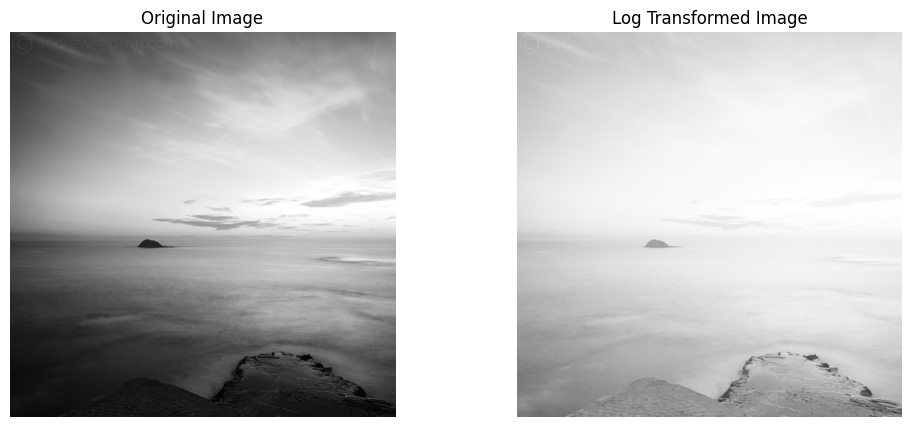

True

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

img = cv2.imread('/content/nstu.jpg',0)

plt.figure(figsize=(12,5))
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.subplot(1,2,1)
plt.imshow(rgb)
plt.axis("off")
plt.title("Original Image")

##
rows, cols = img.shape

c = 255 / math.log(256)

log_img = np.zeros((rows, cols), dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        r = int(img[i, j])

        s = c * math.log(1 + r)

        log_img[i, j] = int(s)

log_rgb = cv2.cvtColor(log_img, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,2)
plt.imshow(log_rgb)
plt.axis("off")
plt.title("Log Transformed Image")
plt.show()

cv2.imwrite('log_transformed.bmp', log_img)


Inverse Log

$$r=e^{s/c} - 1$$

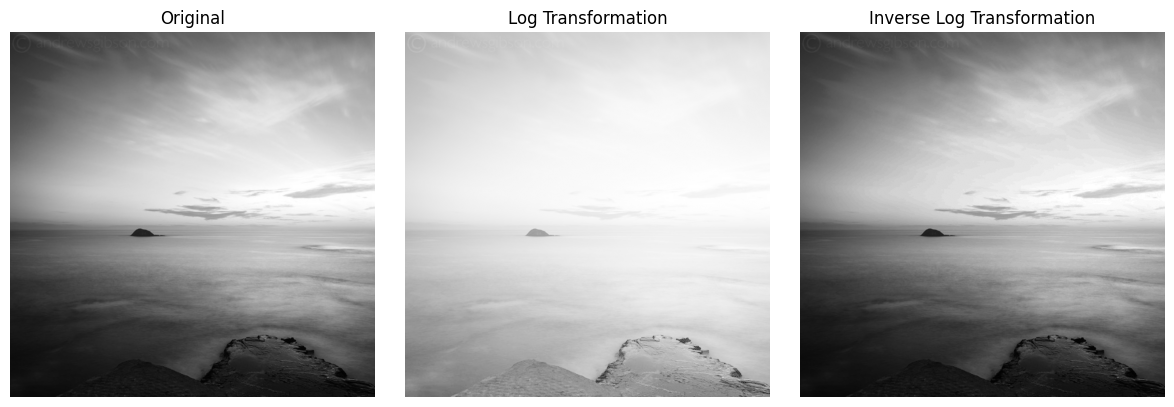

True

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

img = cv2.imread("/content/nstu.jpg", cv2.IMREAD_GRAYSCALE)

rows, cols = img.shape

# --------------------------------
# Log Transformation
# s = c * log(1 + r)
# --------------------------------

c = 255 / math.log(256)

log_img = np.zeros((rows, cols), dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        r = int(img[i, j])

        s = c * math.log(1 + r)

        log_img[i, j] = int(s)


# --------------------------------
# Inverse Log Transformation
# r = e^(s/c) - 1
# --------------------------------

inverse_log = np.zeros((rows, cols), dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        s = int(log_img[i, j])

        r = math.exp(s / c) - 1

        # Keep value between 0 and 255
        if r < 0:
            r = 0
        elif r > 255:
            r = 255

        inverse_log[i, j] = int(r)




plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(log_img, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(inverse_log, cmap="gray")
plt.title("Inverse Log Transformation")
plt.axis("off")

plt.tight_layout()
plt.show()




cv2.imwrite("log_image.bmp", log_img)
cv2.imwrite("inverse_log_image.bmp", inverse_log)

**2.** You are given an image perform power-law transformation. Save the output image in BMP file.

$$s=cr^γ$$


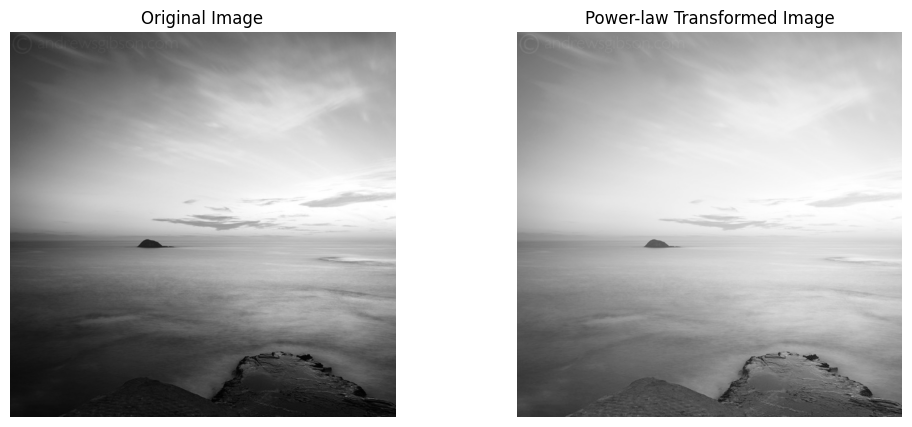

True

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/nstu.jpg',0)

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(rgb)
plt.axis("off")
plt.title("Original Image")

gamma = 0.5
r = img / 255.0;
s=np.power(r,gamma)
s=s*255
s=s.astype(np.uint8)
s_rgb = cv2.cvtColor(s, cv2.COLOR_BGR2RGB)


plt.subplot(1,2,2)
plt.imshow(s_rgb)
plt.axis("off")
plt.title("Power-law Transformed Image")
plt.show()


cv2.imwrite("power_image.bmp", s)


**3.** Draw histogram for any given image.

*cv2.calcHist(images, channels, mask, histSize, ranges)*

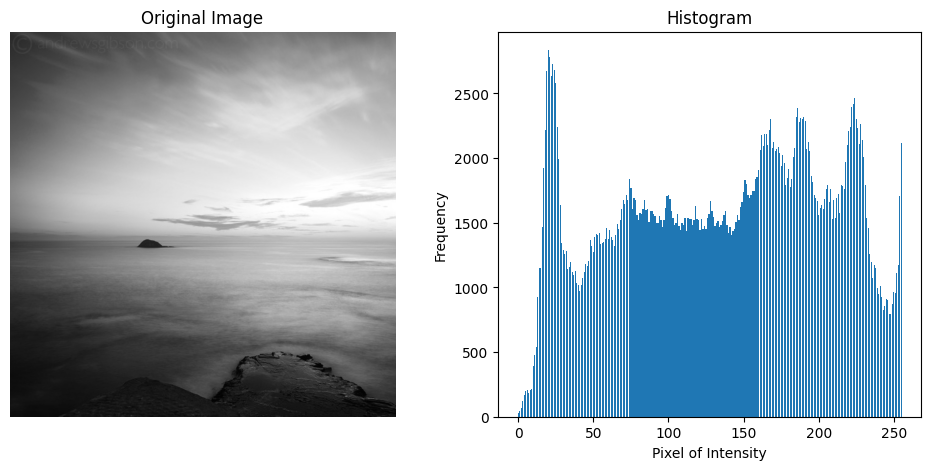

In [15]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/nstu.jpg', 0)

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(rgb)
plt.axis("off")
plt.title("Original Image")

hist = [0]*256
for pixel in img.ravel():
    hist[pixel] += 1

plt.subplot(1,2,2)
plt.bar(
    range(256),
    hist
)
plt.xlabel("Pixel of Intensity")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()

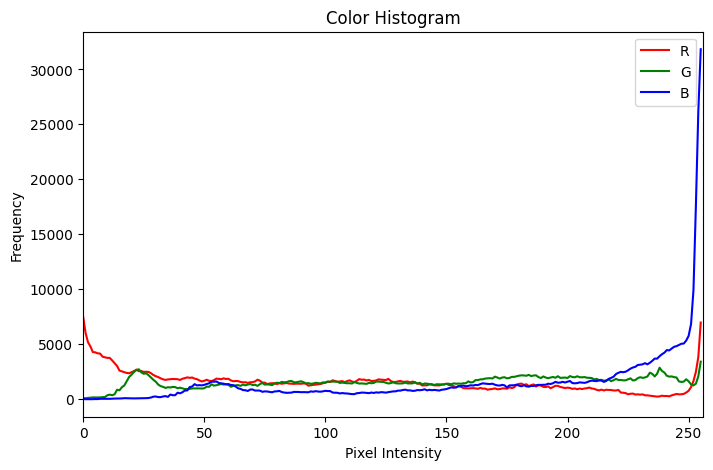

In [16]:
## Working with more than one channel suing cv2
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/nstu.jpg')
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))

for i, color in enumerate(['r', 'g', 'b']):
    hist = cv2.calcHist([rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, label=color.upper())

plt.title("Color Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.show()

**4.** Draw histogram for any image, equalize the histogram and show the equalized image.

**Solution:**
Image

Manual Histogram

CDF : Cumulative Distribution Function.

$$CDF(r_k) = r{r_0}+h(r_1)+...+h(r_k)$$

Transfomration Function
$$s_k = \frac{CDF(r_k) - CDF_{min}}{MN - CDF_{min}} (L-1)$$


New Pixel Value

Eqalized Image

Manual Histogram

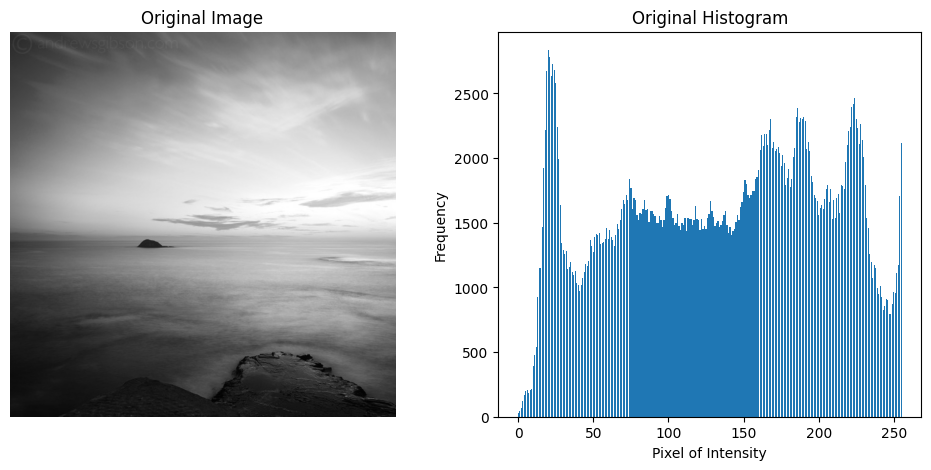

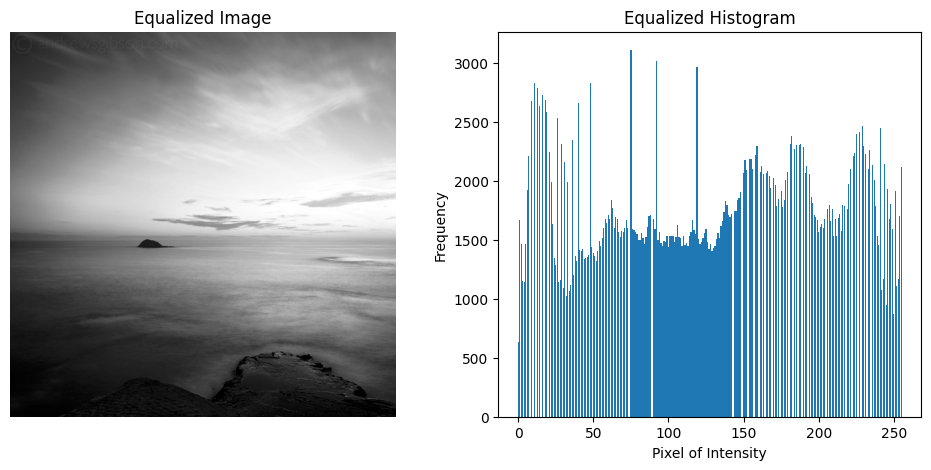

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('/content/nstu.jpg', 0)

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hist = [0]*256

for pixel in img.ravel():
    hist[pixel] += 1

total_pixels = img.size

cdf = [0]*256
cdf[0] = hist[0]

for i in range(1,256):
  cdf[i] = cdf[i-1] + hist[i]

cdf_min = next(value for value in cdf if value > 0)

L = 256
lookup = [0]*256

for i in range(256):
  lookup[i] = round(
      ((cdf[i] - cdf_min) / (total_pixels - cdf_min)) * (L-1)
  )


equalized = np.zeros_like(img)
for i in range(img.shape[0]):
  for j in range(img.shape[1]):
    equalized[i,j] = lookup[img[i,j]]


equalized_hist = [0]*256
for pixel in equalized.ravel():
    equalized_hist[pixel] += 1

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(rgb)
plt.axis("off")
plt.title("Original Image")

plt.subplot(1,2,2)
plt.bar(
    range(256),
    hist
)
plt.xlabel("Pixel of Intensity")
plt.ylabel("Frequency")
plt.title("Original Histogram")
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(equalized, cmap='gray')
plt.axis("off")
plt.title("Equalized Image")

plt.subplot(1,2,2)
plt.bar(
    range(256),
    equalized_hist,
)
plt.xlabel("Pixel of Intensity")
plt.ylabel("Frequency")
plt.title("Equalized Histogram")
plt.show()





**5.** Perform subtraction of two given images. Show the histogram equalized image.

Two Image -> Resize (Make the size equal of both images) -> Substract -> Equalization

*subtracted = cv2.subtract(img1, img2)*, Builtin function

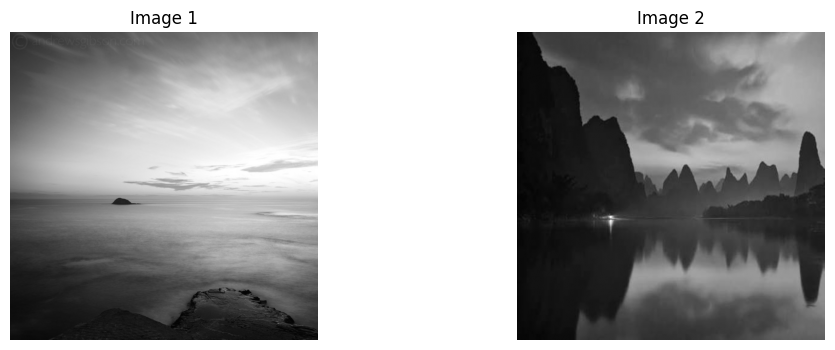

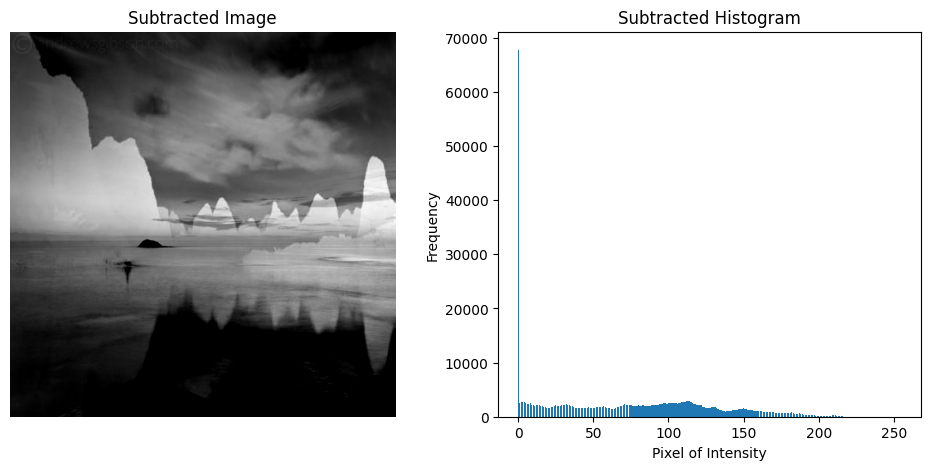

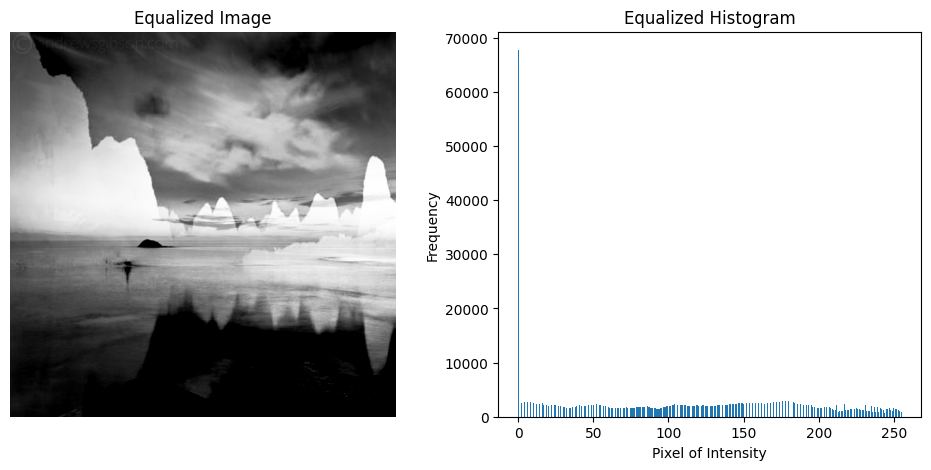

In [35]:

import cv2
import matplotlib.pyplot as plt
import numpy

img1 = cv2.imread("/content/nstu.jpg",0)
img2 = cv2.imread("/content/Bilall.jpg",0)

img2 = cv2.resize(img2,(img1.shape[1],img1.shape[0]))


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(img1, cmap='gray')
plt.axis("off")
plt.title("Image 1")

plt.subplot(1,2,2)
plt.imshow(img2, cmap='gray')
plt.axis("off")
plt.title("Image 2")
plt.show()


subtracted = np.zeros_like(img1)

for i in range(img1.shape[0]):
    for j in range(img1.shape[1]):
        value = int(img1[i, j]) - int(img2[i, j])
        if value < 0:
            value = 0
        subtracted[i, j] = value

hist = [0]*256
for pixel in subtracted.ravel():
    hist[pixel] += 1

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(subtracted, cmap="gray")
plt.axis("off")
plt.title("Subtracted Image")

plt.subplot(1,2,2)
plt.bar(
    range(256),
    hist
)
plt.xlabel("Pixel of Intensity")
plt.ylabel("Frequency")
plt.title("Subtracted Histogram")
plt.show()


cdf = [0]*256
cdf[0] = hist[0]

for i in range(1,256):
  cdf[i] = cdf[i-1] + hist[i]

cdf_min = next(value for value in cdf if value > 0)

total_pixels = subtracted.size

L = 256
lookup = [0]*256
for i in range(256):
  lookup[i] = round(
      ((cdf[i] - cdf_min) / (total_pixels - cdf_min)) * (L-1)
  )


equalized = numpy.zeros_like(subtracted)
for i in range(subtracted.shape[0]):
  for j in range(subtracted.shape[1]):
    equalized[i,j] = lookup[subtracted[i,j]]


equalized_hist = [0]*256
for pixel in equalized.ravel():
    equalized_hist[pixel] += 1

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(equalized, cmap='gray')
plt.axis("off")
plt.title("Equalized Image")

plt.subplot(1,2,2)
plt.bar(
    range(256),
    equalized_hist,
)
plt.xlabel("Pixel of Intensity")
plt.ylabel("Frequency")
plt.title("Equalized Histogram")
plt.show()





**6.** Add any two given images. Show and write the result into a file in BMP format.

Make equal size of both images

Then,
*cv2.add(img1, img2)*

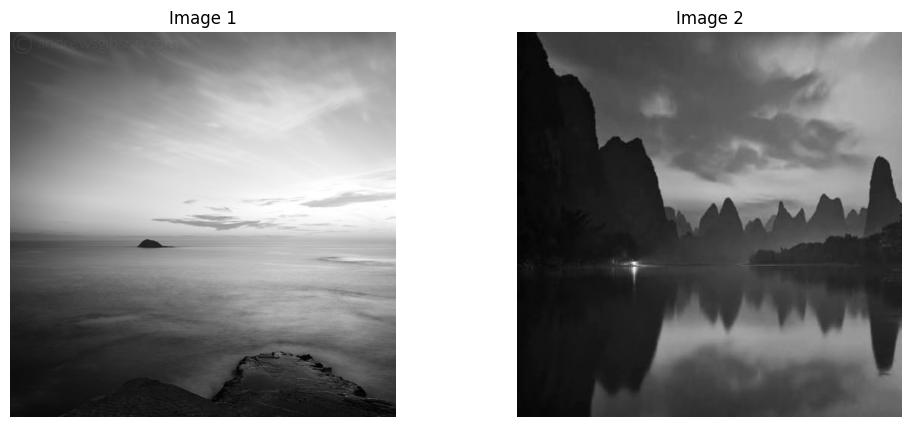

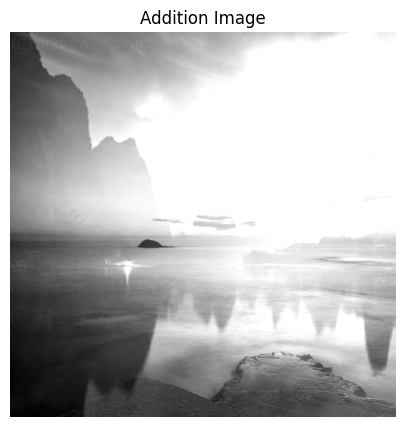

True

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('/content/nstu.jpg',0)
img2 = cv2.imread('/content/Bilall.jpg',0)

img2 = cv2.resize(img2,(img1.shape[1],img1.shape[0]))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img1, cmap='gray')
plt.axis("off")
plt.title("Image 1")

plt.subplot(1,2,2)
plt.imshow(img2, cmap='gray')
plt.axis("off")
plt.title("Image 2")
plt.show()

# addition = cv2.add(img1,img2)

addition = np.zeros_like(img1)
for i in range(img1.shape[0]):
  for j in range(img1.shape[1]):
    op = int(img1[i,j]) + int(img2[i,j])
    if op > 255:
      op = 255
    addition[i,j] = op

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(addition, cmap='gray')
plt.axis("off")
plt.title("Addition Image")
plt.show()

cv2.imwrite("addition_two.bmp", addition)

**7.**  You are given an image. Make it smooth using smoothing filter (filter size may be varied).

$$n\times n \text{ Smoothing filter}$$
$$H_{n\times n} = \frac{1}{n\cdot n}
\begin{bmatrix}
1 & 1 & ... & 1 \\
1 & 1 & ... & 1 \\
1 & 1 & ... & 1 \\
\end{bmatrix}$$

For every pixel output,
$$g(x,y)=\frac{1}{n\cdot n} \sum\sum f(x+i,y+j)$$


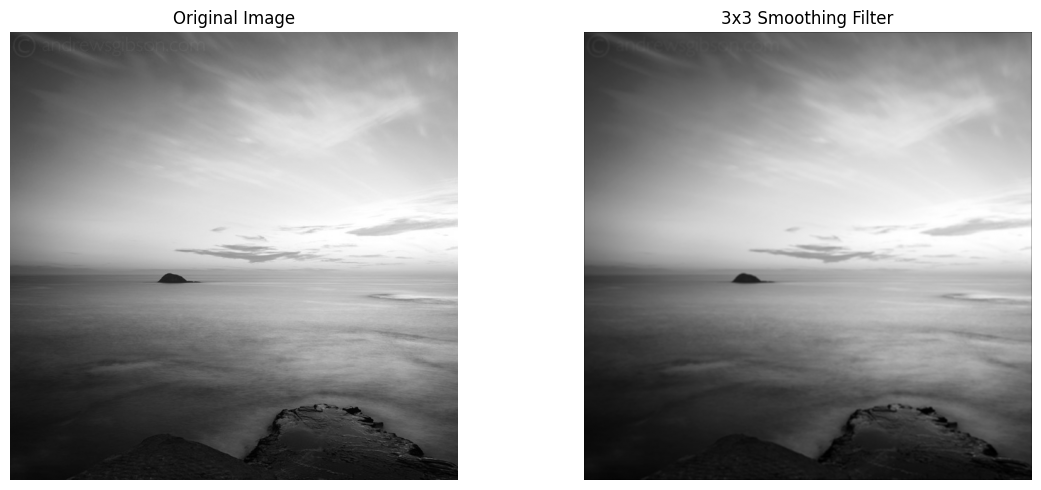

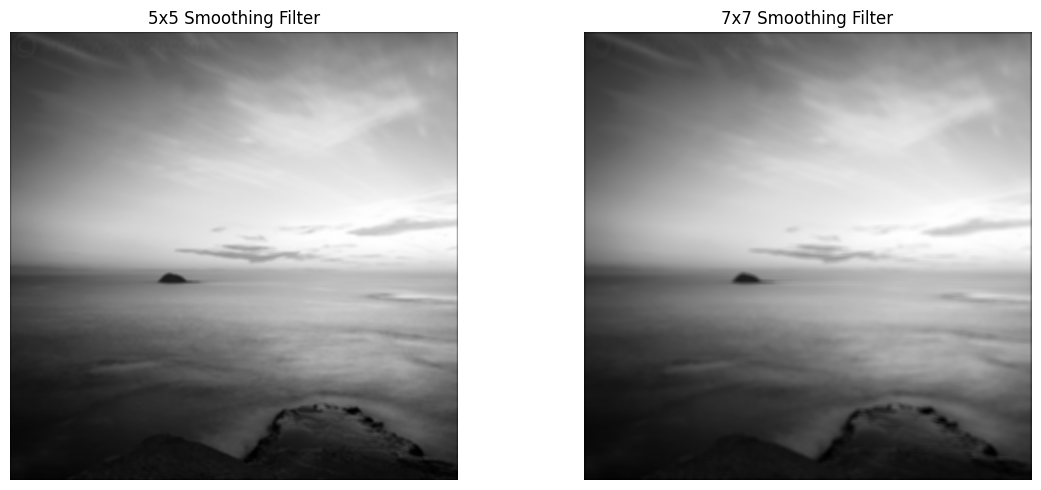

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/nstu.jpg', 0)


def smoothing_filter(filter_size):
    pad = filter_size // 2

    img_padded = np.pad(
        img,
        ((pad, pad), (pad, pad)),
        mode="constant"
    )

    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            total = 0
            for x in range(filter_size):
                for y in range(filter_size):
                     total += int(img_padded[i + x, j + y])
            output[i, j] = int(total / (filter_size ** 2))
    return output


img1 = smoothing_filter(3)
img2 = smoothing_filter(5)
img3 = smoothing_filter(7)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(img1, cmap='gray')
plt.axis("off")
plt.title("3x3 Smoothing Filter")

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img2, cmap='gray')
plt.axis("off")
plt.title("5x5 Smoothing Filter")

plt.subplot(1, 2, 2)
plt.imshow(img3, cmap='gray')
plt.axis("off")
plt.title("7x7 Smoothing Filter")

plt.tight_layout()
plt.show()

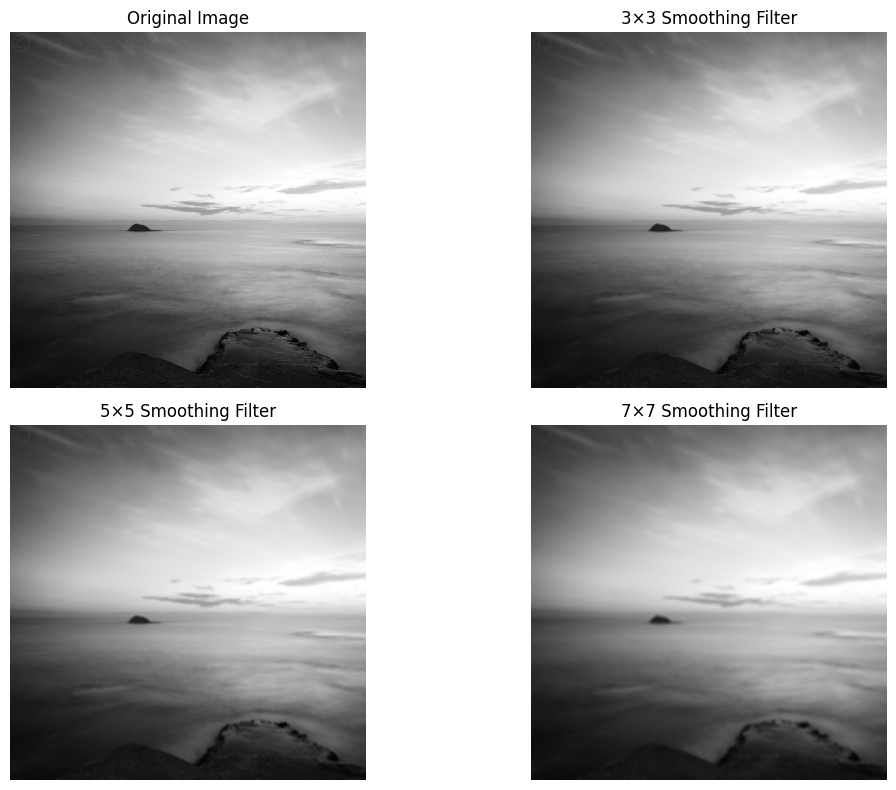

In [21]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("/content/nstu.jpg",0)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

smooth_3 = cv2.blur(img, (3, 3))
smooth_5 = cv2.blur(img, (5, 5))
smooth_7 = cv2.blur(img, (7, 7))

smooth_3_rgb = cv2.cvtColor(smooth_3, cv2.COLOR_BGR2RGB)
smooth_5_rgb = cv2.cvtColor(smooth_5, cv2.COLOR_BGR2RGB)
smooth_7_rgb = cv2.cvtColor(smooth_7, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(smooth_3_rgb)
plt.title("3×3 Smoothing Filter")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(smooth_5_rgb)
plt.title("5×5 Smoothing Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(smooth_7_rgb)
plt.title("7×7 Smoothing Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

**Lecture : 4**

Fourier Spectrum and Phase Angle calculation using Python Calculation Steps:

i) Compute 2D FFT ii) Shift Zero Frequency iii) Calculate Magnitude (Spectrum) iv) Calculate Phase Angle

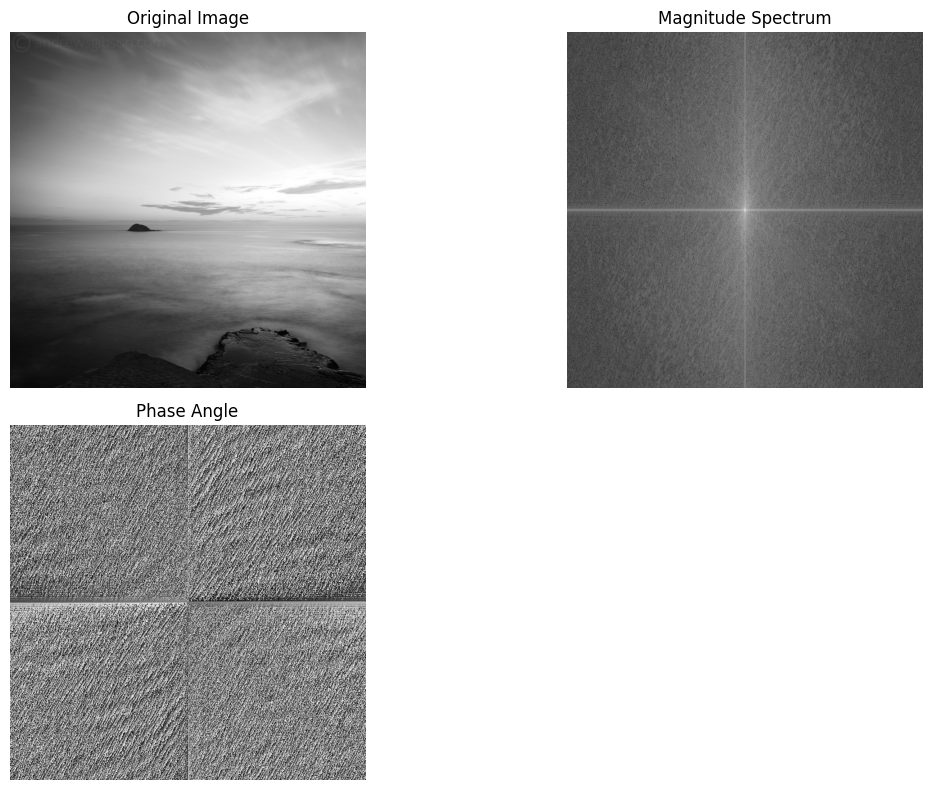

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/nstu.jpg", 0)

img_fft = np.fft.fft2(img)
img_fft_shift = np.fft.fftshift(img_fft)
img_magnitude = 20*np.log(np.abs(img_fft_shift) + 1)
img_phase = np.angle(img_fft_shift)


plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img_magnitude, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(img_phase, cmap='gray')
plt.title("Phase Angle")
plt.axis("off")

plt.tight_layout()
plt.show()



# **Classroom**

**1.** Vertical Flip

Vertical: *img_rgb[::-1, :]*

Horizontal: *img_rgb[:, ::-1]*

Both: *img_rgb[::-1, ::-1]*


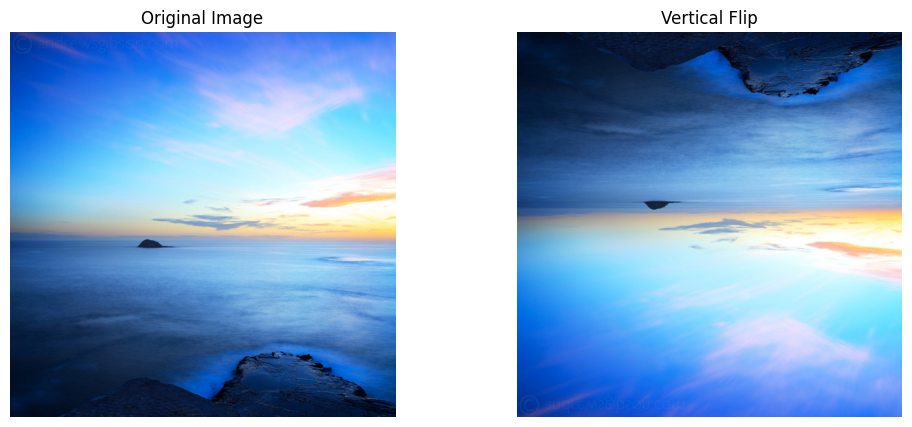

In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('/content/nstu.jpg')


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

flipped = img_rgb[::-1]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(flipped)
plt.axis("off")
plt.title("Vertical Flip")
plt.show()



**2.** Grayscale

$$Gray=0.114B+0.587G+0.299R$$

OR,

**img=cv2.imread('/content/nstu.jpg', 0)**



Why I need to use cmap="gray" ?

Matplotlib doesn't automatically know that your numbers represent brightness. For a 2D array, imshow() uses its default colormap, which is usually viridi
low values  → purple/blue
middle       → green
high values  → yellow

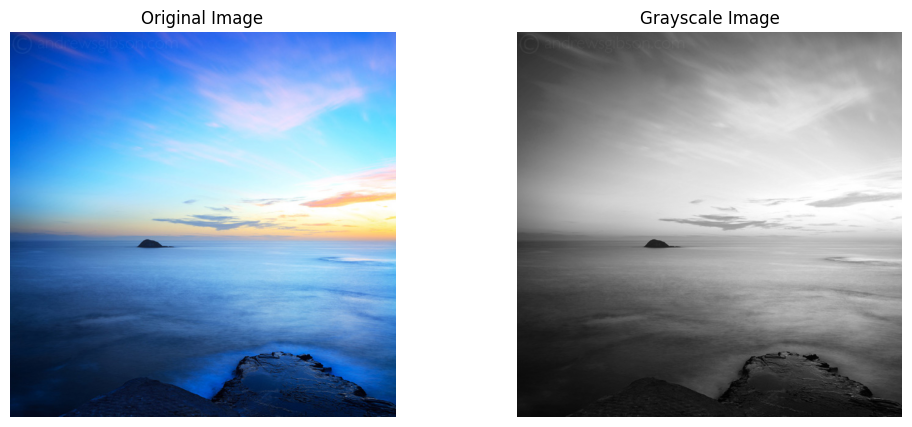

In [24]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/nstu.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = 0.299 * img_rgb[:,:, 0] + 0.587*img_rgb[:,:, 1] + 0.114*img_rgb[:,:,2]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Grayscale Image")
plt.show()

## cv2.imwrite("grayscale.jpg", gray)


**3.**  Entropy Calculation

1. Convert to Grayscale
2. Calculate Histogram
3. Probability
$$P(i) = \frac{H(i)}{\text{rows}\times\text{cols}}$$
4. Entropy
  $$S=-\sum_{0}^{255} P(i) \log_2 P(i)$$

Entropy,  7.911552437501789


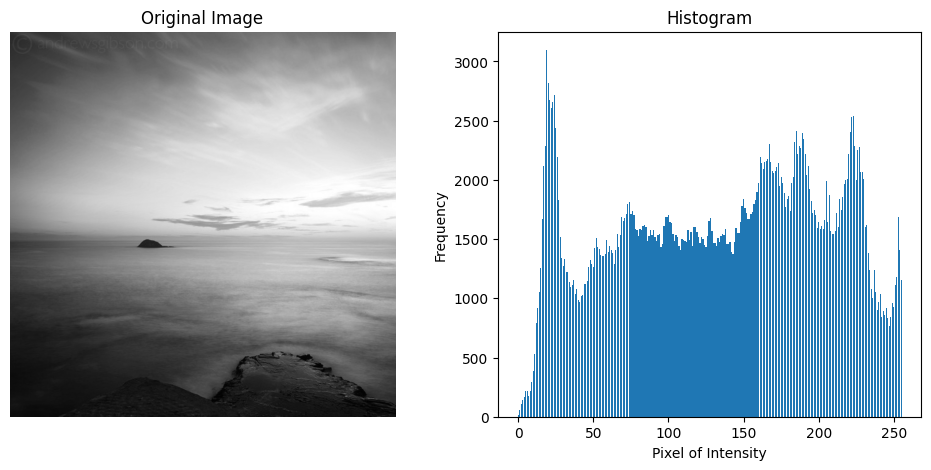

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math


img = cv2.imread("/content/nstu.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = (
    0.299 * img_rgb[:, :, 0]
    + 0.587 * img_rgb[:, :, 1]
    + 0.114 * img_rgb[:, :, 2]
).astype(np.uint8)


rows,cols,ch = img.shape
total_pixels = rows*cols

hist = [0]*256;

for i in range(rows):
  for j in range(cols):
    hist[img_gray[i,j]] += 1

entropy = 0.0

for i in range(256):
  if hist[i] !=0:
    p = hist[i]/total_pixels
    entropy += -p*math.log2(p)


print("Entropy, ", entropy)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap="gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1,2,2)
plt.bar(
    range(256),
    hist
)
plt.xlabel("Pixel of Intensity")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()


**3.** Huffman encoding and decoding for $n \times n$ matrix

In [29]:
import numpy as np
import heapq

np.random.seed(10)

img = np.random.randint(0,10,(4,4))

## img = [[1,2,3], [4,5,6], [7,8,9]]

print("Original 8x8 matrix:")
print(img)


frequency = {}
for row in img:
  for pixel in row:
    if pixel not in frequency:
      frequency[pixel] = 0
    frequency[pixel] += 1

print("\nFrequency of pixels:")
for pixel in sorted(frequency):
  print(f"{pixel}: {frequency[pixel]}")



## Huffman Tree
class Node:
  def __init__(self, freq, symbol, left=None, right=None):
    self.freq = freq
    self.symbol = symbol
    self.left = left
    self.right = right

  def __lt__(self, other):
    return self.freq < other.freq

heap = []
for symbol, freq in frequency.items():
  heapq.heappush(heap, Node(freq, symbol))

while len(heap) > 1:
  left = heapq.heappop(heap)
  right = heapq.heappop(heap)

  newNode = Node(left.freq+right.freq, None, left, right)
  heapq.heappush(heap, newNode)


##  Huffman Codes
codes = {}
def generate_code(node, code=""):
  if node.symbol is not None:
    codes[node.symbol] = code
  else:
    generate_code(node.left, code + "0")
    generate_code(node.right, code + "1")

generate_code(heap[0])
print("\nHuffman Codes:")
for symbol, code in codes.items():
  print(f"{symbol}: {code}")


## Encoding
encoded = ""
for row in img:
  for pixel in row:
    encoded += codes[pixel]

print("\nEncoded string:")
print(encoded)

## Decoding
decode_map = {v: k for k, v in codes.items()}
decoded = []
current_code = ""
for bit in encoded:
  current_code += bit
  if current_code in decode_map:
    decoded.append(decode_map[current_code])
    current_code = ""

decoded = np.array(decoded).reshape(img.shape)
print("\nDecoded matrix:")
print(decoded)

print("Original size:", img.size * 8, "bits")
print("Compression size:", len(encoded), "bits")
print("Compression ratio:", len(encoded) / (img.size * 8))

Original 8x8 matrix:
[[9 4 0 1]
 [9 0 1 8]
 [9 0 8 6]
 [4 3 0 4]]

Frequency of pixels:
0: 4
1: 2
3: 1
4: 3
6: 1
8: 2
9: 3

Huffman Codes:
9: 00
0: 01
1: 100
6: 1010
3: 1011
8: 110
4: 111

Encoded string:
0011101100000110011000011101010111101101111

Decoded matrix:
[[9 4 0 1]
 [9 0 1 8]
 [9 0 8 6]
 [4 3 0 4]]
Original size: 128 bits
Compression size: 43 bits
Compression ratio: 0.3359375
